# Mapas de las provincias y las macro regiones

In [1]:
import os
import sys

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)
from constantes import *
import pandas as pd
import geopandas as gpd

In [2]:
DIR_DATOS_ORI = os.path.join(DIR_DATOS, "originales")

DIR_SHAPE = os.path.join(DIR_DATOS_ORI, "shape_files")


In [3]:
Arg = gpd.read_file(DIR_SHAPE+"/pxdptodatosok.shp")
Arg = Arg.drop(Arg.query("link in('94028','94021')").index, axis = 0) 
Arg = Arg.to_crs(EPSG)

In [4]:
geo_provincias = []
for prov in Arg.provincia.unique():
    g = Arg.geometry[Arg.provincia== prov].copy()
    geo_provincias.append(g.union_all())

geo_provincias = gpd.GeoSeries(geo_provincias)

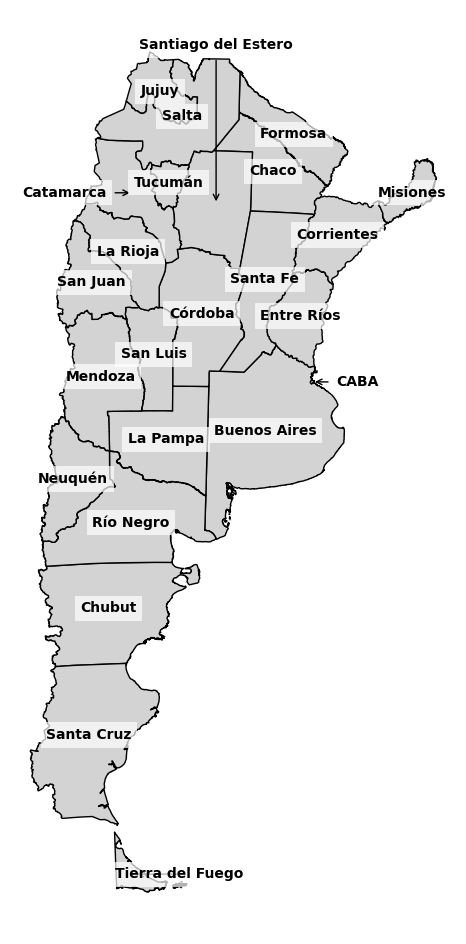

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 12))
geo_provincias.plot(ax=ax, color='lightgray', edgecolor='black')

nombres_provincias = Arg.provincia.unique()

offsets = [
    (0, 1),    # arriba
    (0, -1),   # abajo
    (1, 0),    # derecha
    (-1, 0),   # izquierda
    (1, 1),    # arriba-derecha
    (-1, 1),   # arriba-izquierda
    (1, -1),   # abajo-derecha
    (-1, -1),  # abajo-izquierda
]
Factor = 100000
for idx, (geom, nombre) in enumerate(zip(geo_provincias, nombres_provincias)):
    if geom.is_empty:
        continue
    c = geom.centroid
    # Alternar posiciones para evitar superposición
    dx, dy = 0,0# offsets[idx % len(offsets)]
    if nombre == 'Catamarca':
        dx, dy = -3, 0 # Ajustar posición para Catamarca
    elif nombre == 'Santiago del Estero':
        dx, dy = 0, 7 # Ajustar posición para Santiago del Estero
    elif nombre == 'Ciudad Autónoma de Buenos Aires':
        dx, dy = 2, 0
        nombre = 'CABA'
    elif nombre == 'Tierra del Fuego':
        dx, dy = 2, 0
        
    # Ajustar el desplazamiento (puedes modificar el factor 2 según el tamaño del mapa)
    offset_x = c.x + dx * Factor
    offset_y = c.y + dy * Factor
    ax.annotate(
        nombre,
        xy=(c.x, c.y),
        xytext=(offset_x, offset_y),
        ha='center', va='center',
        fontsize=10, fontweight='bold',
        arrowprops=dict(arrowstyle="->", color='black', lw=1),
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')
    )

ax.set_axis_off()
plt.show()

In [6]:
regiones = {
    'Cuyo': ['Mendoza', 'San Juan', 'San Luis'],
    'Noroeste': ['Catamarca', 'Jujuy', 'La Rioja', 'Salta', 'Tucumán'],
    'Noreste': ['Chaco', 'Corrientes', 'Formosa', 'Misiones', 'Santiago del Estero'],
    'Pampeana': ['Buenos Aires', 'Ciudad Autónoma de Buenos Aires','Córdoba', 'Santa Fe', 'La Pampa', 'Entre Ríos'],
    'Patagonia': ['Chubut', 'Neuquén', 'Río Negro', 'Santa Cruz', 'Tierra del Fuego']
}

geo_regiones = []

for reg in regiones.keys():
    filtro = Arg['provincia'].isin(regiones[reg]).values
    g = Arg[filtro].copy()
    geo_regiones.append(g.union_all())

geo_regiones = gpd.GeoSeries(geo_regiones)

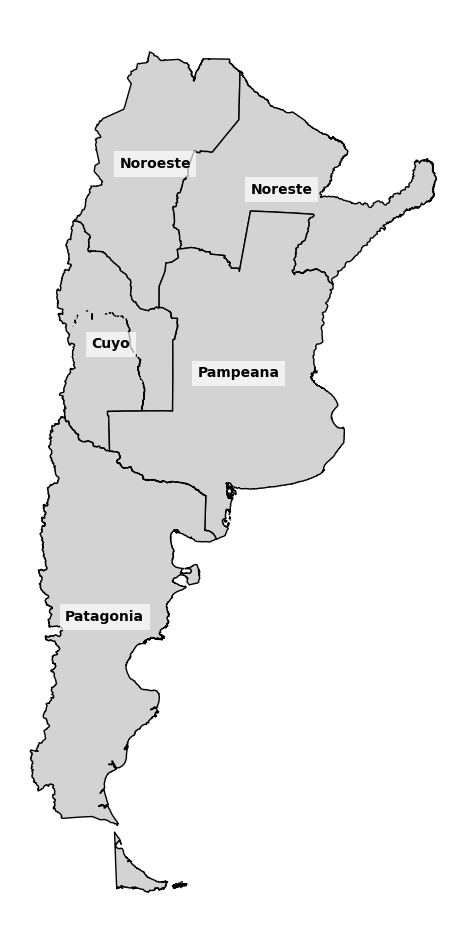

In [7]:

fig, ax = plt.subplots(figsize=(12, 12))
geo_regiones.plot(ax=ax, color='lightgray', edgecolor='black')

nombres_regiones = regiones.keys()

Factor = 100000
for idx, (geom, nombre) in enumerate(zip(geo_regiones, nombres_regiones)):
    if geom.is_empty:
        continue
    c = geom.centroid
    # Alternar posiciones para evitar superposición
    dx, dy = 0,0# offsets[idx % len(offsets)]
       
    # Ajustar el desplazamiento (puedes modificar el factor 2 según el tamaño del mapa)
    offset_x = c.x + dx * Factor
    offset_y = c.y + dy * Factor
    ax.annotate(
        nombre,
        xy=(c.x, c.y),
        xytext=(offset_x, offset_y),
        ha='center', va='center',
        fontsize=10, fontweight='bold',
        arrowprops=dict(arrowstyle="->", color='black', lw=1),
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')
    )

ax.set_axis_off()
plt.show()